In [46]:
import sys
import os

sys.path.append(os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from helpers import load_data, clean_data

print("setup is complete :)")


setup is complete :)


In [47]:
df_raw = load_data('../data/netflix_titles.csv')
df = clean_data(df_raw)

df.head()

Rows: 8807 | Columns: 12
Missing values:
director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64



/Users/jamiemitchell/Desktop/netflix-content-analysis/src/helpers.py:13: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["director"].fillna("Unknown", inplace=True)
/Users/jamiemitchell/Desktop/netflix-content-analysis/src/helpers.py:14: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained 

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,duration_value,main_genre,primary_country
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,90.0,Documentaries,United States
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,2.0,International TV Shows,South Africa
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,1.0,Crime TV Shows,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,1.0,Docuseries,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,2.0,International TV Shows,India


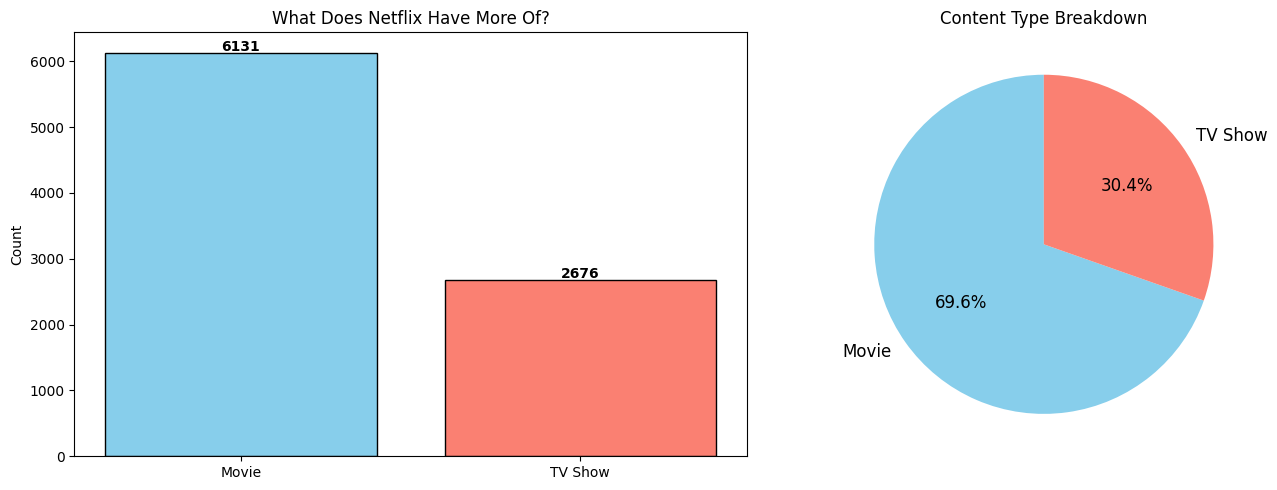

In [48]:
type_counts = df['type'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(type_counts.index, type_counts.values, color=['skyblue', 'salmon'], edgecolor='black')
axes[0].set_title('What Does Netflix Have More Of?')
axes[0].set_ylabel('Count')

for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(
    type_counts.values, 
    labels=type_counts.index, 
    autopct='%1.1f%%', 
    colors=['skyblue', 'salmon'], 
    startangle=90,
    textprops={'fontsize': 12})

axes[1].set_title('Content Type Breakdown')

plt.tight_layout()
plt.savefig('../visuals/content_type_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

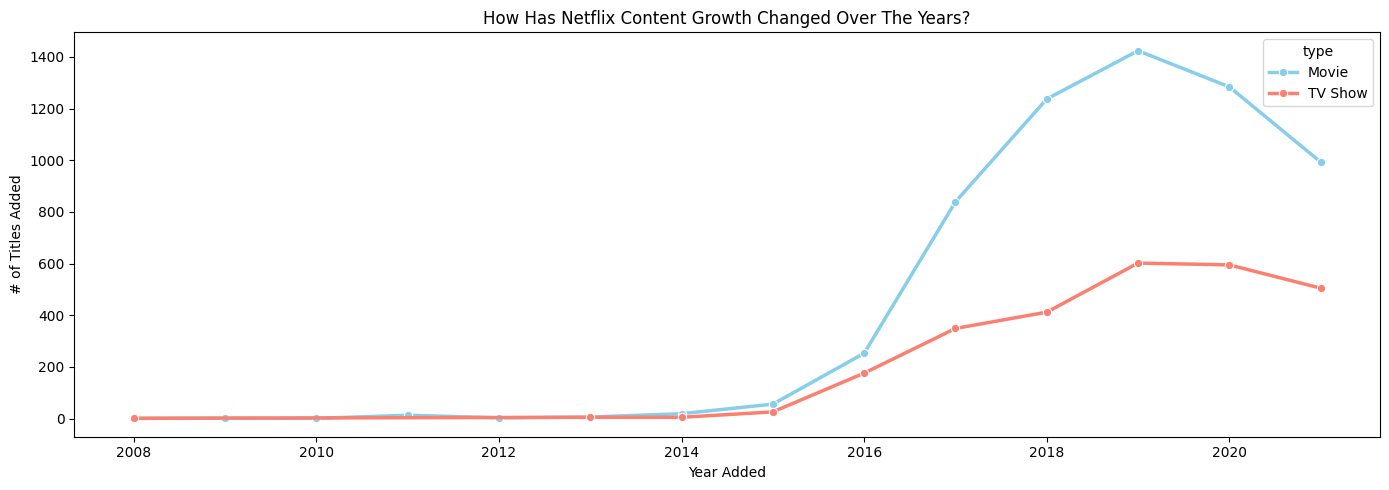

In [49]:
yearly = df.groupby(['year_added', 'type']).size().reset_index(name='count')
yearly = yearly.dropna(subset=['year_added'])

plt.figure(figsize=(14,5))
sns.lineplot(
    data=yearly, 
    x='year_added', 
    y='count', 
    hue='type', 
    palette=['skyblue', 'salmon'],
    linewidth=2.5,
    marker='o')


plt.title('How Has Netflix Content Growth Changed Over The Years?')
plt.xlabel('Year Added')
plt.ylabel('# of Titles Added')

plt.tight_layout()
plt.savefig('../visuals/content_growth_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

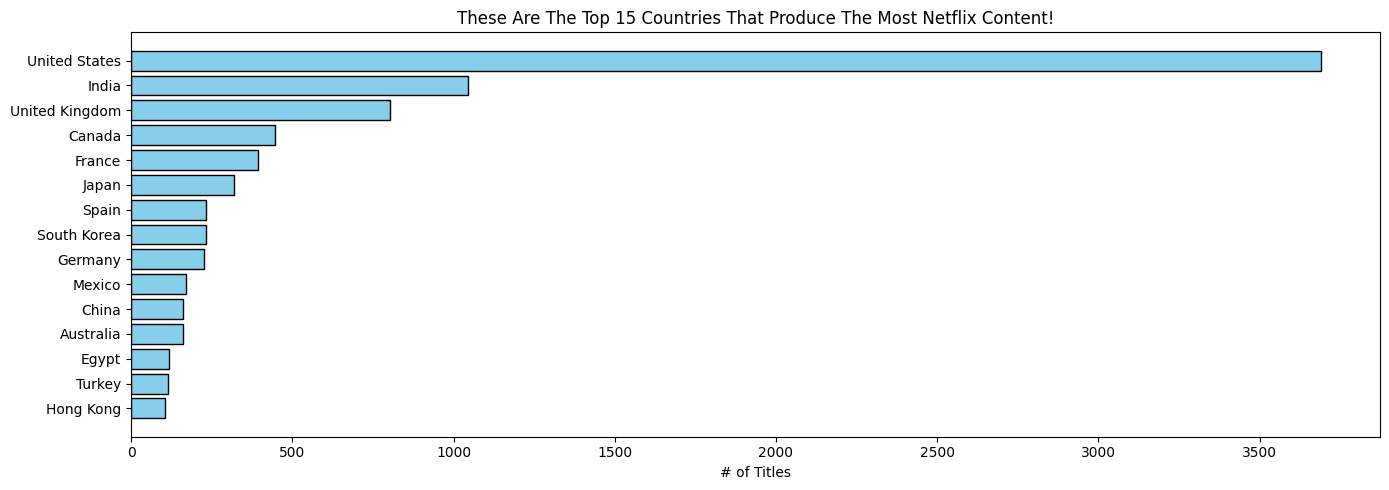

In [50]:
countries = df['country'].str.split(', ').explode()
top_countries = countries[countries != 'Unknown'].value_counts().head(15)

plt.figure(figsize=(14,5))
plt.barh(top_countries.index[::-1], top_countries.values[::-1], color='skyblue', edgecolor='black')


plt.title('These Are The Top 15 Countries That Produce The Most Netflix Content!')
plt.xlabel('# of Titles')

plt.tight_layout()
plt.savefig('../visuals/top_countries.png', dpi=150, bbox_inches='tight')   
plt.show()

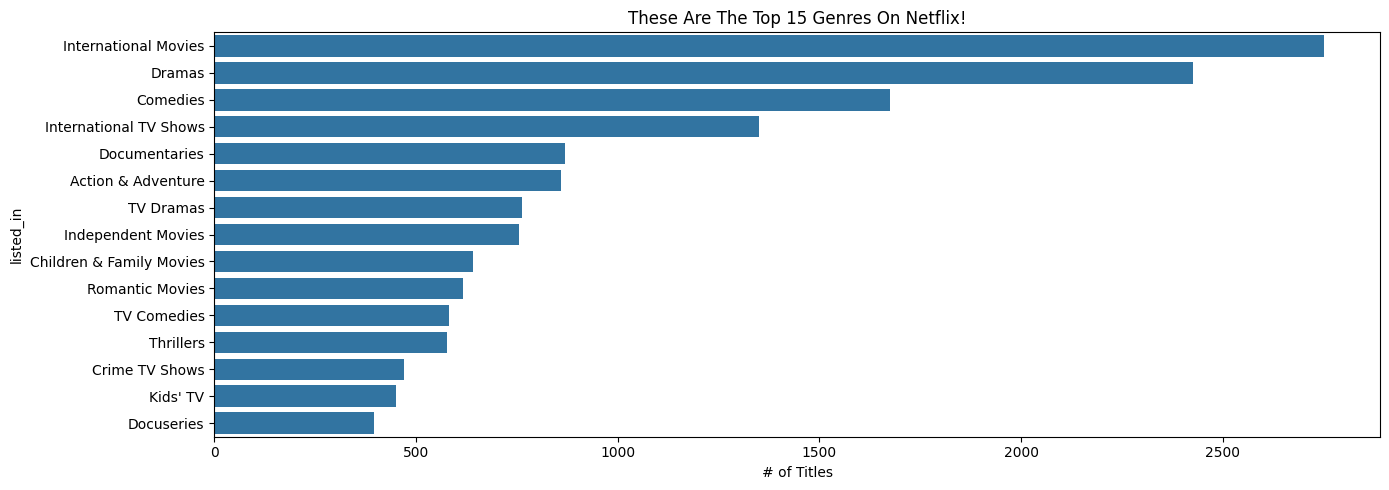

In [51]:
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(15)

plt.figure(figsize=(14,5))
sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title('These Are The Top 15 Genres On Netflix!')
plt.xlabel('# of Titles')

plt.tight_layout()
plt.savefig('../visuals/top_genres.png', dpi=150, bbox_inches='tight')
plt.show()

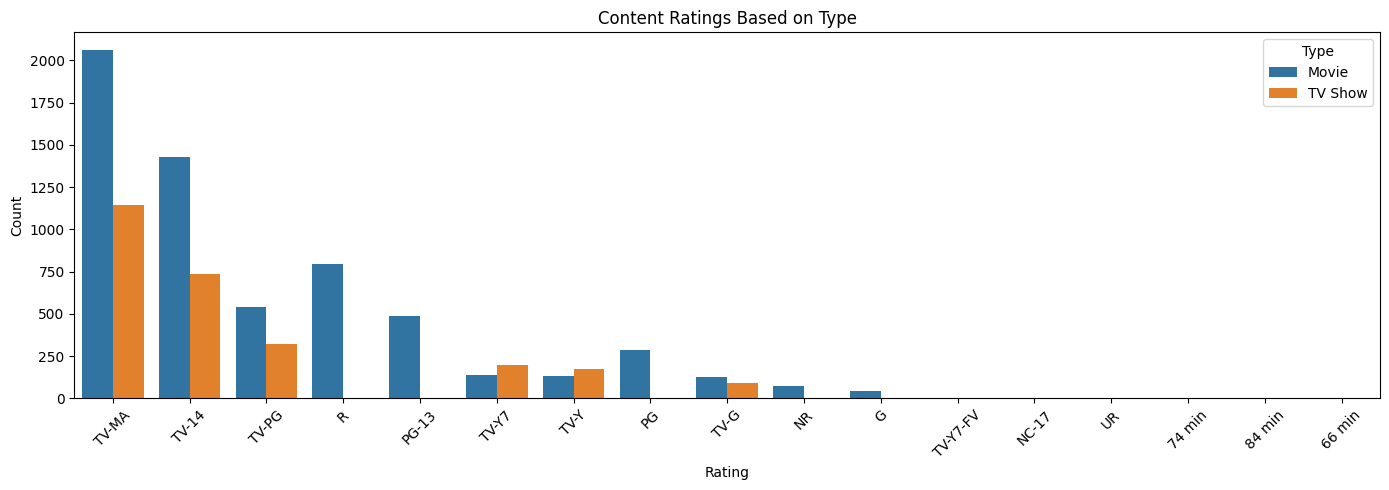

In [52]:
ratings = df['rating'].value_counts().index

plt.figure(figsize=(14,5))
sns.countplot(
    data=df, 
    x='rating', 
    order=ratings,
    hue='type')

plt.title('Content Ratings Based on Type')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Type')

plt.tight_layout()
plt.savefig('../visuals/ratings_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/9t/z1pxf7c14fl43r8m5qrr8k540000gn/T/ipykernel_2033/2347382188.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


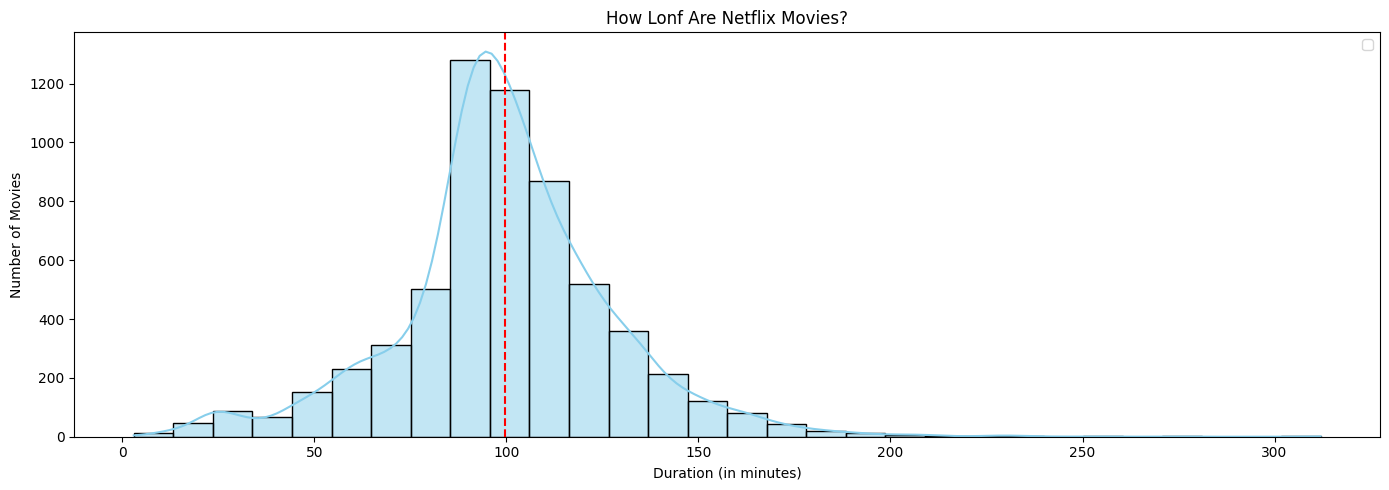

In [53]:
durations = pd.to_numeric(
    df[df['type'] == 'Movie']['duration'].str.replace(' min', ''),
    errors='coerce'
).dropna()

avg_duration = durations.mean()

plt.figure(figsize=(14,5))
sns.histplot(durations, bins=30, kde=True, color='skyblue', edgecolor='black')

plt.axvline(avg_duration, color='red', linestyle='--')
plt.title('How Lonf Are Netflix Movies?')
plt.xlabel('Duration (in minutes)')
plt.ylabel('Number of Movies')

plt.legend()
plt.tight_layout()
plt.savefig('../visuals/movie_durations.png', dpi=150, bbox_inches='tight')
plt.show()

Feature matrix shape: (8807, 5)
Train: 7045 | Test: 1762
Model trained
              precision    recall  f1-score   support

     TV Show       0.99      1.00      1.00       535
       Movie       1.00      1.00      1.00      1227

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



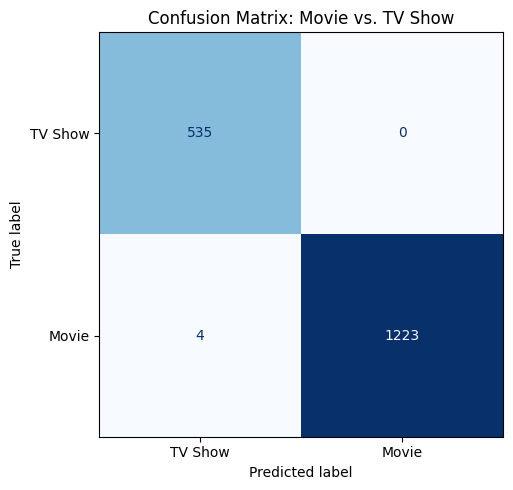

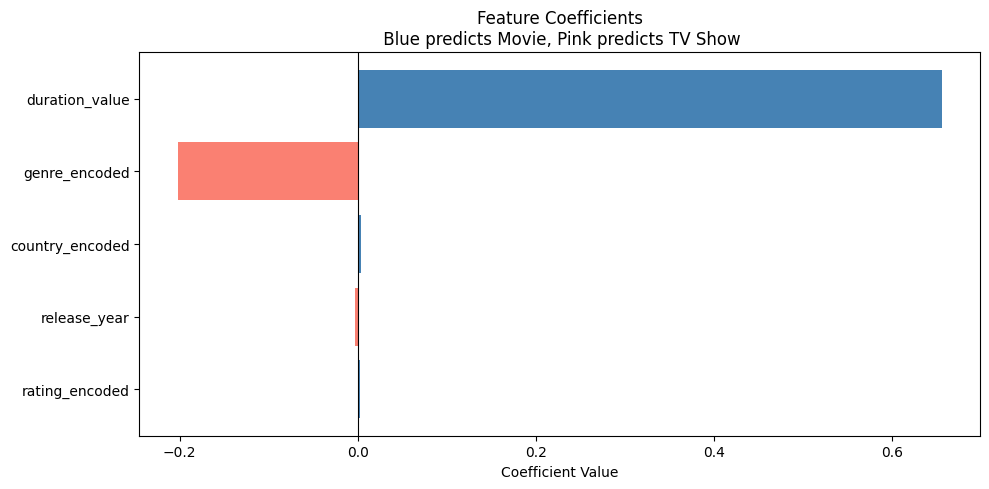

        Feature  Coefficient
 duration_value     0.655863
  genre_encoded    -0.202211
country_encoded     0.003822
   release_year    -0.003453
 rating_encoded     0.002792


In [55]:
ml_df = df.copy()

ml_df['label'] = (ml_df['type'] == 'Movie').astype(int)

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

le = LabelEncoder()
ml_df['rating_encoded']  = le.fit_transform(ml_df['rating'].astype(str))
ml_df['country_encoded'] = le.fit_transform(ml_df['primary_country'].astype(str))
ml_df['genre_encoded']   = le.fit_transform(ml_df['main_genre'].astype(str))

ml_df['duration_value'] = ml_df['duration_value'].fillna(ml_df['duration_value'].median())

features = ['duration_value', 'rating_encoded', 'country_encoded', 'genre_encoded', 'release_year']
X = ml_df[features]
y = ml_df['label']

print(f'Feature matrix shape: {X.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print('Model trained')

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['TV Show', 'Movie']))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['TV Show', 'Movie'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Confusion Matrix: Movie vs. TV Show')
plt.tight_layout()
plt.savefig('../visuals/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df['Coefficient']]
plt.figure(figsize=(10, 5))
plt.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients\n Blue predicts Movie, Pink predicts TV Show')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('../visuals/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(coef_df.to_string(index=False))

## Key Findings:
- Netflix's catalog is dominated by movies (about 70%), which shows that films are essential to its content strategy, this may also be influenced by production cost differences and audience consumption patterns.
- Content production is concentrated in the US, India, and the UK, showing that Netflix not only focuses on strong domestic influence but also international expansion.
- Netflix experienced rapid growth in content additions between the years 2018 and 2019, followed buy a very steep slowdown after 2020, which was likely due to COVID-related distruptions.
- International movies, dramas and comedies are the most common genres, again proving that Netflix likes to appeal to global audiences.
- The logistical regression classifier achieved 100% accuracy on the test set. Duration was the strongest signifier/predictive feature. Movies are measured in minutes, while TV shows are measured in seasons, which makes them more easily separable and easier for the model to achieve very high accuracy.